In [1]:
import os
import glob
import numpy as np
import torch 

In [7]:
from noah2 import data as D
from noah2 import util as U

In [9]:
import corner as DFM
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False
%matplotlib inline

In [5]:
cuda = torch.cuda.is_available()
device = ("cuda:0" if cuda else "cpu")

# non-participant

In [8]:
DNoah = D.Noah2()

data = DNoah.data(sample='non-participants', columns='props', unique_zipcode=True) 

# reduce dynamic scale
data[:,2] = np.log10(data[:,2])
data[:,3] = np.log10(data[:,3])

In [2]:
imodels, losses = [], []
for fl in glob.glob('../../dat/nde_support/nde_nonpart.v0/*loss'): 
    imodels.append(int(fl.split('.')[-2]))
    
    with open(fl, 'rb') as f: 
        losses.append(float(f.readline()))
        
imodels = np.array(imodels)
losses = np.array(losses)

In [3]:
ibest = imodels[np.argmin(losses)]

In [6]:
flow = torch.load('../../dat/nde_support/nde_nonpart.v0/nde_nonpart.v0.%i.pt' % ibest, map_location=device)

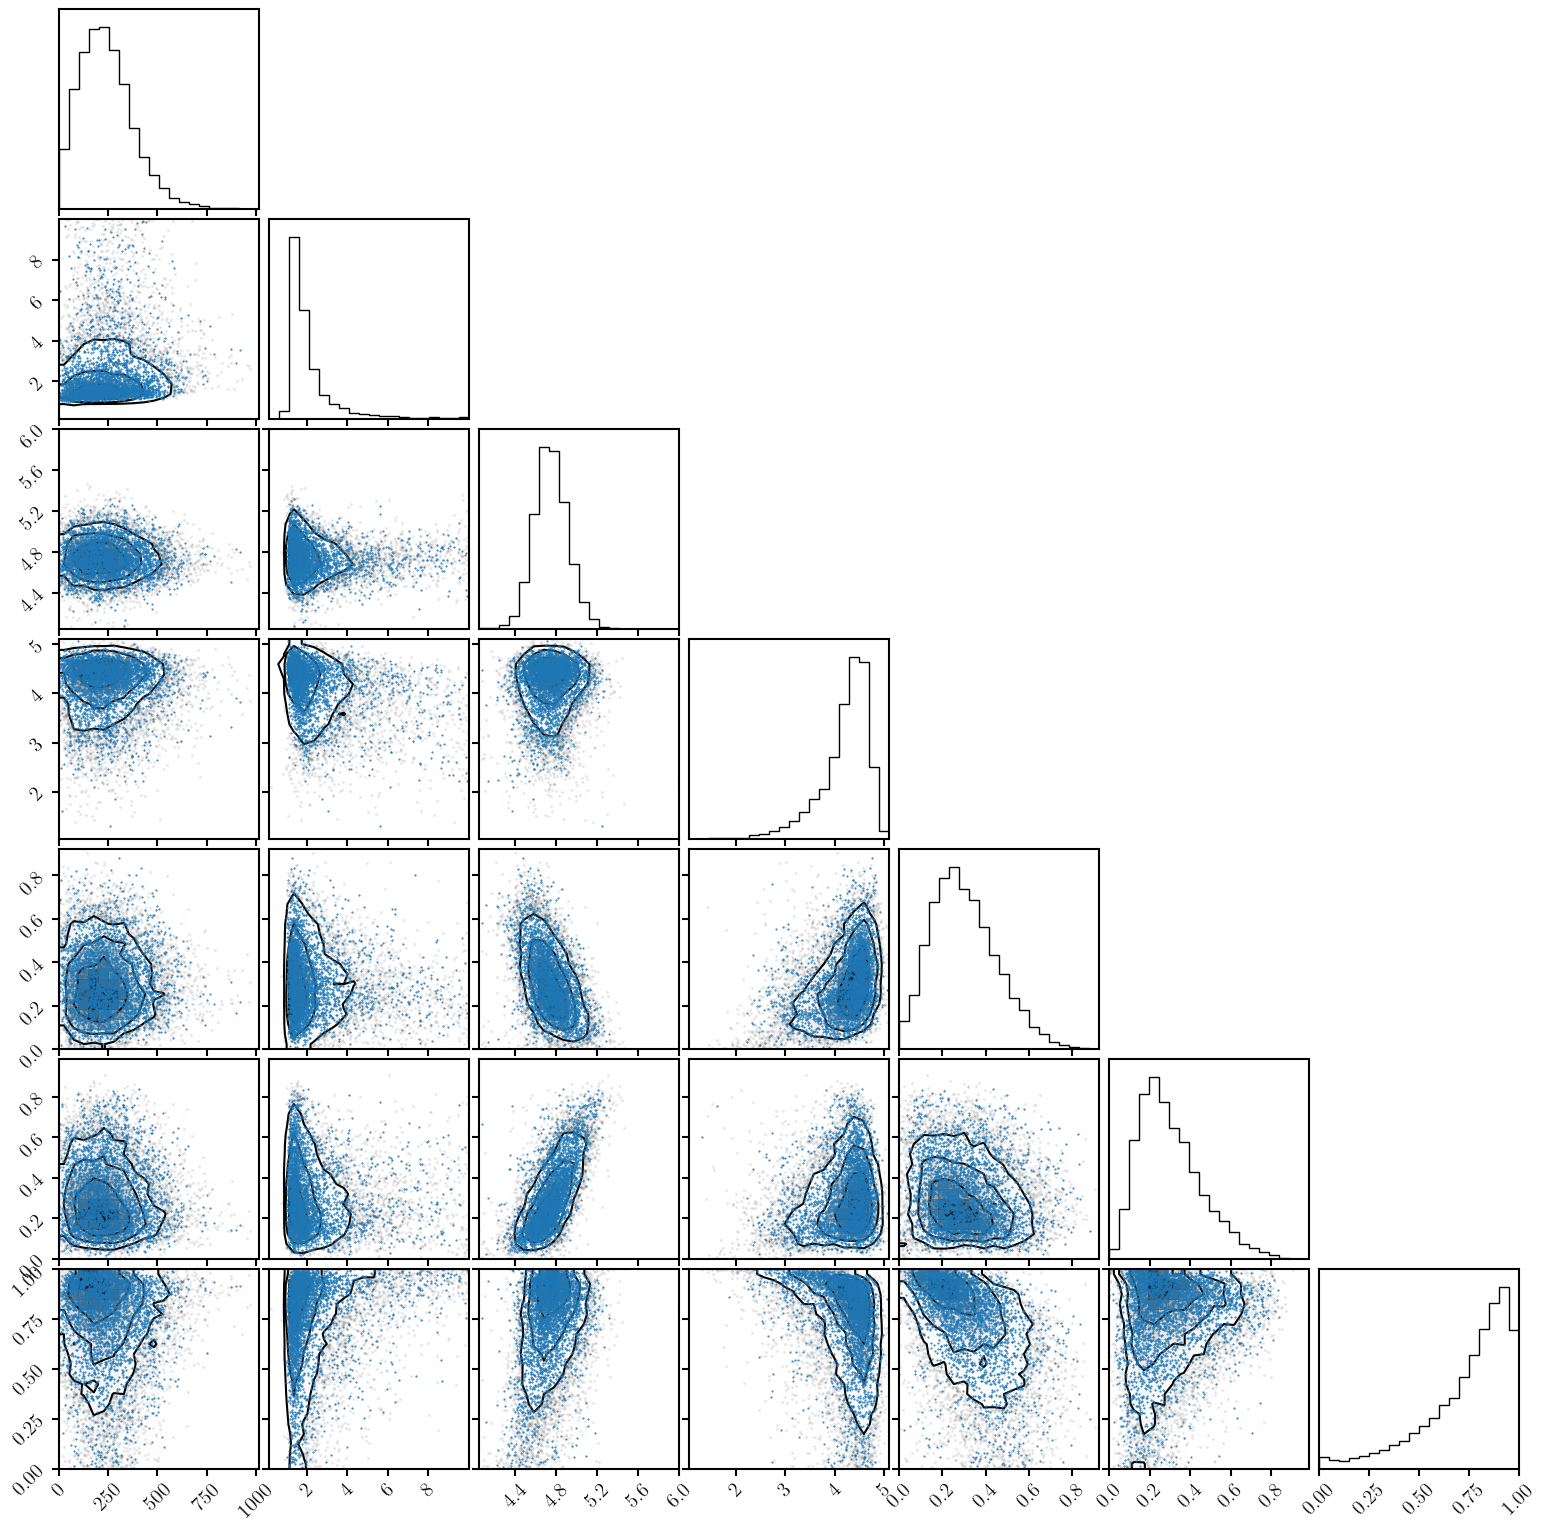

In [12]:
with torch.no_grad(): 
    samp = flow.sample(10000)
    samples = np.array(samp.detach().cpu()).copy()
    samples[:,0] = U.cdf_transform(samples[:,0], [-1e-3, 1500])
    samples[:,1] = U.cdf_transform(samples[:,1], [-1e-3, 10])
    samples[:,2] = U.cdf_transform(samples[:,2], [3, 6])        
    samples[:,3] = U.cdf_transform(samples[:,3], [1, 6])        
    samples[:,4] = U.cdf_transform(samples[:,4], [-1e-3, 1+1e-3])            
    samples[:,5] = U.cdf_transform(samples[:,5], [-1e-3, 1+1e-3])            
    samples[:,6] = U.cdf_transform(samples[:,6], [-1e-3, 1+1e-3])          

fig = DFM.corner(samples)
DFM.overplot_points(fig, data, markersize=1)    
plt.show()